In [1]:
import os
from pathlib import Path

# Setup environment if we are in google colab
USING_COLAB = "google.colab" in str(get_ipython())
if USING_COLAB:
  # Installing packages
  !pip install utide --quiet
  !pip install ipympl --quiet
  !pip freeze > requirements.txt

  # 3rd party widgets
  from google.colab import output
  output.enable_custom_widget_manager()

  # Downloading the repository with data/codes
  if not Path("polm2026").exists():
    !git clone https://github.com/jamal919/polm2026

  # Downloading pycaz
  if not Path("pycaz").exists():
    !git clone https://github.com/jamal919/pycaz
    import sys
    sys.path.append("pycaz")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import cartopy
import cartopy.crs as ccrs
import utide
from scipy import stats
from scipy.stats import genextreme
from scipy.stats import genpareto
from scipy.optimize import approx_fprime
from scipy.optimize import minimize
import warnings

# A package with various utilities
# Pycaz
# https://github.com/jamal919/pycaz
import pycaz.sources.gesla as gesla
import pycaz.sources.uhslc as uhslc
from pycaz.tide.utide import coef2df


if USING_COLAB:
    %matplotlib widget

# Data download

## The University of Hawaii Sea Level Center (UHSLC)
The University of Hawaii Sea Level Center (UHSLC) dataset refers to the collection of global tide gauge sea level data archived and distributed by the center.  It serves as a primary component of the Global Sea Level Observing System (GLOSS) and is a collaboration with the NOAA National Centers for Environmental Information known as the Joint Archive for Sea Level (JASL).

* Fast Delivery (FD): Data released within 1–2 months of collection.  These undergo basic quality control focused on large level shifts and obvious outliers. They are used for real-time applications like tsunami warning and operational oceanography.
* Research Quality Data (RQD): Considered the final science-ready dataset. These undergo thorough, rigorous quality control (including datum evaluation and benchmark ties) but are released with a 1–2 year lag.  RQD is archived at the NOAA NCEI and is the standard for long-term climate research.

In [2]:
df_uhslc_stations = uhslc.query_stations(delivery="research", frequency="hourly")
df_uhslc_stations.describe()

,uhslc_id,latitude,longitude
count,672.000000,672.000000,672.000000
mean,356.089286,7.678678,-10.386866
std,258.317042,28.872591,104.357755
min,6.000000,-77.850000,-177.366700
25%,137.750000,-9.422525,-86.591675
50%,286.000000,11.430000,-42.451650
75%,590.500000,26.151675,99.776320
max,915.000000,78.938300,179.210000


Text(0.5, 1.0, 'UHSLC Coverage')

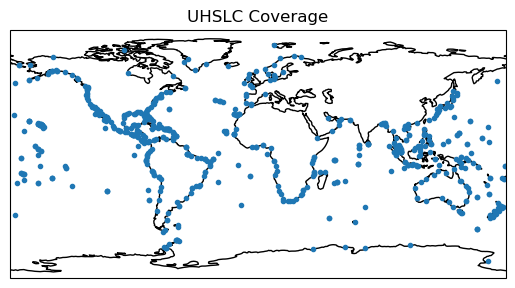

In [3]:
fig, ax = plt.subplots(subplot_kw={"projection":ccrs.PlateCarree()})
ax.plot(df_uhslc_stations.longitude, df_uhslc_stations.latitude, marker=".", linestyle="none")
ax.coastlines()
ax.set_global()
ax.set_title("UHSLC Coverage")

In [4]:
df_uhslc_station_bgd = df_uhslc_stations.loc[df_uhslc_stations.station_country=="Bangladesh"]
df_uhslc_station_bgd = df_uhslc_station_bgd.assign(station_code=df_uhslc_station_bgd.uhslc_id.astype(str)+df_uhslc_station_bgd.version)
df_uhslc_station_bgd

,station_name,station_country,version,uhslc_id,latitude,longitude,station_code
93,Charchanga,Bangladesh,A,138,22.21670,91.05000,138A
101,Chittagong,Bangladesh,A,124,22.23652,91.82518,124A
127,Cox's Bazaar,Bangladesh,A,136,21.45000,91.83330,136A
225,Hiron Point,Bangladesh,A,134,21.78330,89.46670,134A
277,Khal #10,Bangladesh,A,135,22.26670,91.81670,135A
278,Khepupara,Bangladesh,A,139,21.83330,89.83330,139A
621,Teknaf,Bangladesh,A,137,20.88330,92.30000,137A


In [5]:
for i, r in df_uhslc_station_bgd.iterrows():
    print(r.station_name)
    uhslc.download_erddap(
        station_name=r.station_name, 
        uhslc_id=r.uhslc_id, 
        version=r.version, 
        delivery="research", 
        frequency="hourly", 
        outdir="./data/uhslc")

Charchanga
Chittagong
Cox's Bazaar
Hiron Point
Khal #10
Khepupara
Teknaf


## GESLA

GESLA Version 3 (or GESLA-3) is a major update to the Global Extreme Sea Level Analysis dataset, which provides quasi-global, high-frequency (hourly or higher) sea-level measurements from tide gauge stations.


* Sources: Data was compiled from 36 international and national data providers, including records recovered via data archaeology from paper records. 
* Purpose: The dataset is designed to support oceanographic and coastal engineering studies, including the analysis of tides, storm surges, and extreme sea levels.

Reference: Haigh, I. D., Marcos, M., Talke, S. A., Woodworth, P. L., Hunter, J. R., Hague, B. S., Arns, A., Bradshaw, E., & Thompson, P. (2023). GESLA Version 3: A major update to the global higher‐frequency sea‐level dataset.  Geoscience Data Journal, 12(1), 1–14. https://doi.org/10.1002/gdj3.174

In [6]:
df_gesla_stations = gesla.query_stations()
df_gesla_stations.describe()

,latitude,longitude
count,6640.000000,6640.000000
mean,35.168775,-41.686346
std,23.972736,80.613514
min,-77.850100,-178.160200
25%,29.519130,-90.883950
50%,39.780000,-73.918350
75%,51.620962,5.332925
max,82.880000,179.210000


Text(0.5, 1.0, 'GESLA Coverage')

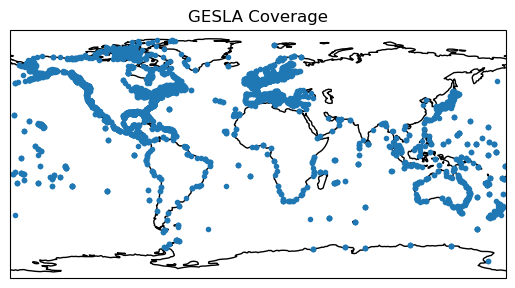

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection":ccrs.PlateCarree()})
ax.plot(df_gesla_stations.longitude, df_gesla_stations.latitude, marker=".", linestyle="none")
ax.coastlines()
ax.set_global()
ax.set_title("GESLA Coverage")

In [8]:
df_gesla_stations_bgd = df_gesla_stations.loc[df_gesla_stations.station_country_code=="BGD"]
df_gesla_stations_bgd

,latitude,longitude,record_id,agency_id,station_name,station_code,station_country_code
1053,20.883,92.300,teknaf-137a-bgd-uhslc_rq,UHSLC_RQ,Teknaf,137A,BGD
1091,21.450,91.833,coxs_bazaar-136a-bgd-uhslc_rq,UHSLC_RQ,Coxs_Bazaar,136A,BGD
1096,21.783,89.467,hiron_point-134a-bgd-uhslc_rq,UHSLC_RQ,Hiron_Point,134A,BGD
1097,21.833,89.833,khepupara-139a-bgd-uhslc_rq,UHSLC_RQ,Khepupara,139A,BGD
1105,22.217,91.050,charchanga-138a-bgd-uhslc_rq,UHSLC_RQ,Charchanga,138A,BGD
1106,22.237,91.827,chittagong-124-bgd-uhslc_fd,UHSLC_FD,Chittagong,124,BGD
1107,22.247,91.825,chittagong-124a-bgd-uhslc_rq,UHSLC_RQ,Chittagong,124A,BGD
1111,22.267,91.817,khal_10-135a-bgd-uhslc_rq,UHSLC_RQ,Khal_10,135A,BGD


In [9]:
# Downloading
for record_id in df_gesla_stations_bgd.record_id:
    print(record_id)
    gesla.download_erddap(record_id=record_id, outdir="data/gesla")

teknaf-137a-bgd-uhslc_rq
coxs_bazaar-136a-bgd-uhslc_rq
hiron_point-134a-bgd-uhslc_rq
khepupara-139a-bgd-uhslc_rq
charchanga-138a-bgd-uhslc_rq
chittagong-124-bgd-uhslc_fd
chittagong-124a-bgd-uhslc_rq
khal_10-135a-bgd-uhslc_rq


# Data coverage

In [10]:
df_stations = pd.merge(
    df_gesla_stations_bgd, 
    df_uhslc_station_bgd\
        .drop(columns=["longitude", "latitude"])\
        .rename(columns={"station_name":"uhslc_station_name"}), 
    on="station_code")

df_stations = df_stations.drop(columns=["agency_id", "station_country_code", "station_country"])

def format_stn_name(name:str) -> str:
    """Format the station name to remove space

    Args:
        name (str): name string

    Returns:
        str: formatted name string
    """
    name = str(name)
    name = name.replace(" ", "_")
    name = name.replace("-", "_")
    name = name.replace("'", "")
    return name

df_stations = df_stations.assign(uhslc_fn=df_stations.apply(lambda r: f"{format_stn_name(r.uhslc_station_name)}_{r.uhslc_id}_{r.version}.csv", axis=1))
df_stations = df_stations.assign(gesla_fn=df_stations.record_id + ".csv")
df_stations

,latitude,longitude,record_id,station_name,station_code,uhslc_station_name,version,uhslc_id,uhslc_fn,gesla_fn
0,20.883,92.300,teknaf-137a-bgd-uhslc_rq,Teknaf,137A,Teknaf,A,137,Teknaf_137_A.csv,teknaf-137a-bgd-uhslc_rq.csv
1,21.450,91.833,coxs_bazaar-136a-bgd-uhslc_rq,Coxs_Bazaar,136A,Cox's Bazaar,A,136,Coxs_Bazaar_136_A.csv,coxs_bazaar-136a-bgd-uhslc_rq.csv
2,21.783,89.467,hiron_point-134a-bgd-uhslc_rq,Hiron_Point,134A,Hiron Point,A,134,Hiron_Point_134_A.csv,hiron_point-134a-bgd-uhslc_rq.csv
3,21.833,89.833,khepupara-139a-bgd-uhslc_rq,Khepupara,139A,Khepupara,A,139,Khepupara_139_A.csv,khepupara-139a-bgd-uhslc_rq.csv
4,22.217,91.050,charchanga-138a-bgd-uhslc_rq,Charchanga,138A,Charchanga,A,138,Charchanga_138_A.csv,charchanga-138a-bgd-uhslc_rq.csv
5,22.247,91.825,chittagong-124a-bgd-uhslc_rq,Chittagong,124A,Chittagong,A,124,Chittagong_124_A.csv,chittagong-124a-bgd-uhslc_rq.csv
6,22.267,91.817,khal_10-135a-bgd-uhslc_rq,Khal_10,135A,Khal #10,A,135,Khal_#10_135_A.csv,khal_10-135a-bgd-uhslc_rq.csv


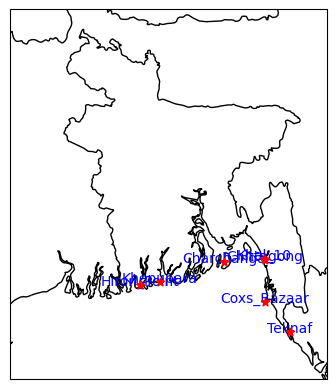

In [11]:
fig, ax = plt.subplots(subplot_kw={"projection":ccrs.PlateCarree()})
ax.scatter(df_stations.longitude, df_stations.latitude, marker="*", color="red", zorder=100)
for i, r in df_stations.iterrows():
    ax.annotate(r.station_name, xy=[r.longitude, r.latitude], ha="center", color="blue")
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.set_extent([87, 93, 20, 27])

In [12]:
def get_non_nan_blocks(series):
    """
    Returns a list of [begin_index, end_index] for contiguous non-NaN blocks.
    Indices correspond to series.index labels.
    """
    is_not_na = series.notna().to_numpy()
    if not np.any(is_not_na):
        return []

    # Pad with False to detect boundary transitions at edges
    padded = np.concatenate(([False], is_not_na, [False]))
    diff = np.diff(padded.astype(int))

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return [[series.index[s], series.index[e]] for s, e in zip(starts, ends)]

Now for each station, let us look at the coverage of the timeseries from these two dataset. For the group who will look into Chittagong (5), please also look into data/gesla/chittagong-124-bgd-uhslc_fd.csv dataset. By default, we are looking at data/gesla/chittagong-124-bgd-uhslc_rq.csv.

UHSLC: 26.955738078941366 Years
GESLA: 26.955738078941366 Years


Text(0.5, 1.0, 'Hiron_Point')

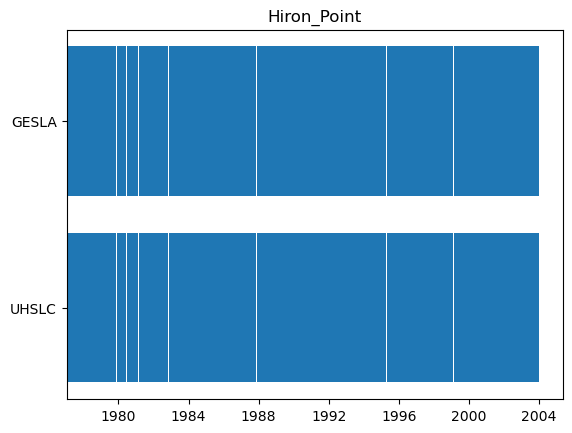

In [13]:
stnid = 2
stn = df_stations.loc[stnid]

stn_name = stn.station_name
df_uhslc = uhslc.read_erddap(f"./data/uhslc/{stn.uhslc_fn}")
df_gesla = gesla.read_erddap(f"./data/gesla/{stn.gesla_fn}")

availability_uhslc = get_non_nan_blocks(df_uhslc.Elev)
print(f"UHSLC: {(df_uhslc.index[-1]-df_uhslc.index[0])/pd.Timedelta("365.25D")} Years")

availability_gesla = get_non_nan_blocks(df_gesla.Elev)
print(f"GESLA: {(df_gesla.index[-1]-df_gesla.index[0])/pd.Timedelta("365.25D")} Years")

fig, ax = plt.subplots()
availabilities = [availability_uhslc, availability_gesla]
ticklabels = ["UHSLC", "GESLA"]
ticks = []

colors = ["tab:blue", "tab:green"]
for i, (availability, color) in enumerate(zip(availabilities, colors)):
    ticks.append(i)
    for block in availability:
        ax.barh(i, width=block[1]-block[0], left=block[0], color="tab:blue")


ax.set_yticks(ticks)
ax.set_yticklabels(["UHSLC", "GESLA"])
ax.set_title(stn_name)

Text(0, 0.5, 'Difference between two dataset')

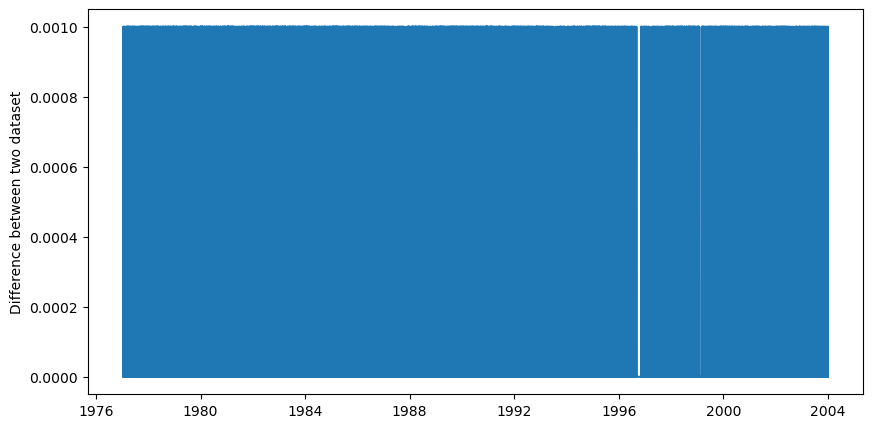

In [14]:
# Data value comparison

fig, ax = plt.subplots(figsize=(10, 5))
df_gesla_uhslc = df_gesla - df_uhslc
ax.plot(df_gesla_uhslc.index, df_gesla_uhslc)
ax.set_ylabel("Difference between two dataset")

For consistency, we will use the gesla dataset for the rest of the notebook.

In [15]:
df = df_gesla # You can switch to df_uhslc too, but some of the code may not work

# Timeseries

In [16]:
df

,Elev,Flag1,Flag2
Datetime,,,
1977-01-16 03:00:00,1.83,1,1
1977-01-16 04:00:00,1.55,1,1
1977-01-16 05:00:00,1.25,1,1
1977-01-16 06:00:00,1.00,1,1
1977-01-16 07:00:00,0.79,1,1
...,...,...,...
2003-12-31 13:00:00,2.19,1,1
2003-12-31 14:00:00,1.97,1,1
2003-12-31 15:00:00,1.71,1,1


There are three columns:

- Elev: contains the data
- Flag1: 0 - no quality control, 1 - correct value, 2 - interpolated value, 3 - doubtful value, 4 - isolated spike or wrong value, 5 - missing value
- Flag2: 1 = use, 0 = do not use

In [17]:
print(f"Number of Flagged data: {np.sum(df.Flag2!=1)}")

Number of Flagged data: 1980


In [18]:
# Let us use only "1" flagged data
df = df.where(df.Flag2==1)
df

,Elev,Flag1,Flag2
Datetime,,,
1977-01-16 03:00:00,1.83,1.0,1.0
1977-01-16 04:00:00,1.55,1.0,1.0
1977-01-16 05:00:00,1.25,1.0,1.0
1977-01-16 06:00:00,1.00,1.0,1.0
1977-01-16 07:00:00,0.79,1.0,1.0
...,...,...,...
2003-12-31 13:00:00,2.19,1.0,1.0
2003-12-31 14:00:00,1.97,1.0,1.0
2003-12-31 15:00:00,1.71,1.0,1.0


In [19]:
# We can access the first column by df.Elev, which will give us a series
df.Elev

Datetime
1977-01-16 03:00:00    1.83
1977-01-16 04:00:00    1.55
1977-01-16 05:00:00    1.25
1977-01-16 06:00:00    1.00
1977-01-16 07:00:00    0.79
                       ... 
2003-12-31 13:00:00    2.19
2003-12-31 14:00:00    1.97
2003-12-31 15:00:00    1.71
2003-12-31 16:00:00    1.46
2003-12-31 17:00:00    1.30
Name: Elev, Length: 236295, dtype: float64

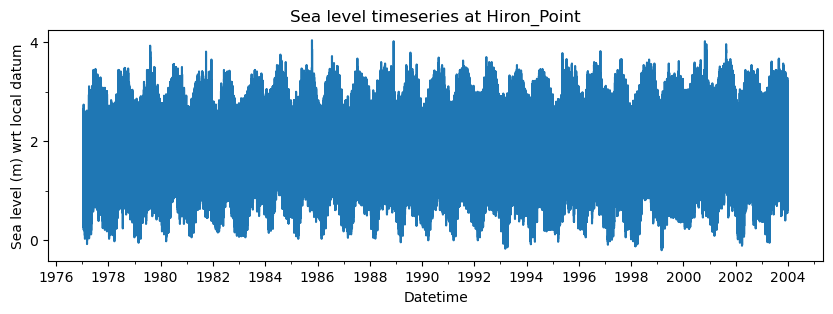

In [20]:
# We can now plot this time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_gesla.index, df_gesla.Elev)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.set(xlabel="Datetime", ylabel="Sea level (m) wrt local datum", title=f"Sea level timeseries at {stn_name}")
plt.show()

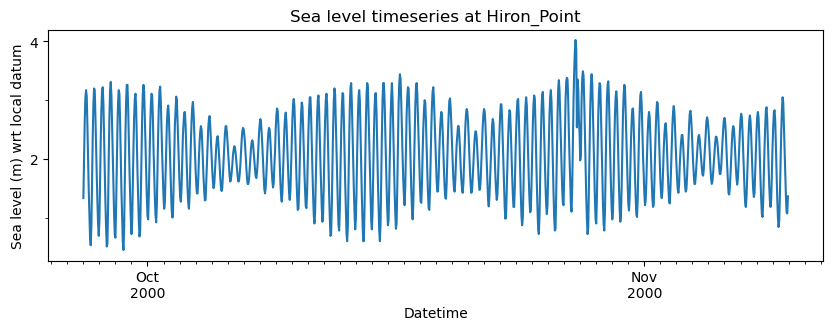

In [21]:
# Let us zoom into some timeslice
timeslice = slice("2000-09-27", "2000-11-09")
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df.loc[timeslice].index, df.loc[timeslice].Elev)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.set(xlabel="Datetime", ylabel="Sea level (m) wrt local datum", title=f"Sea level timeseries at {stn_name}")
plt.show()

Go see in the Wikipedia, if you can find a storm corresponding to this peak. We can also cross-check with storm dataset, but will not be shown here. For storm dataset, a good source is https://www.ncei.noaa.gov/products/international-best-track-archive.

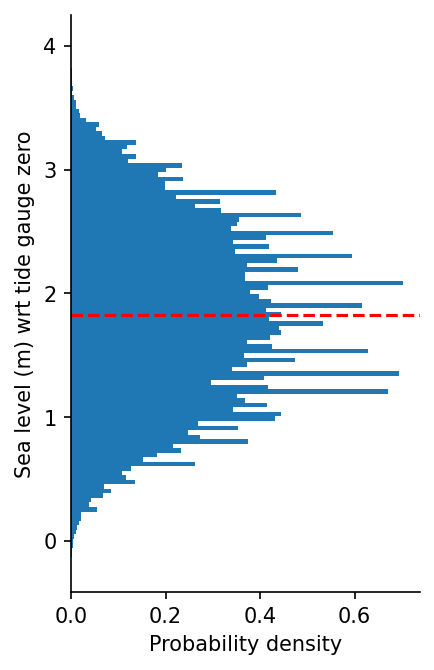

In [22]:
# How does the distribution of water level looks like?
# Compare with what was shown in the class

fig, ax = plt.subplots(figsize=(3, 5), dpi=150)
freq, bins = np.histogram(df.Elev.dropna(), bins="fd", density=True)
ords = (bins[0:-1] + bins[1:])/2
height = np.diff(bins)
ax.barh(ords, freq, height=height)

mean = df.Elev.mean()
ax.axhline(mean, color="red", linestyle="--")
# ax.annotate(text=f"Mean: {mean:0.2f}m", xy=[0.245, mean+0.1 ])

ax.set_ylabel("Sea level (m) wrt tide gauge zero")
ax.set_xlabel("Probability density")
ax.spines["right"].set(visible=False)
ax.spines["top"].set(visible=False)
plt.show()

# Monthly mean sea level and trends

## Trend estimates

0.00585372256351477 0.001854200923222138


(1977.0, 2003.0)

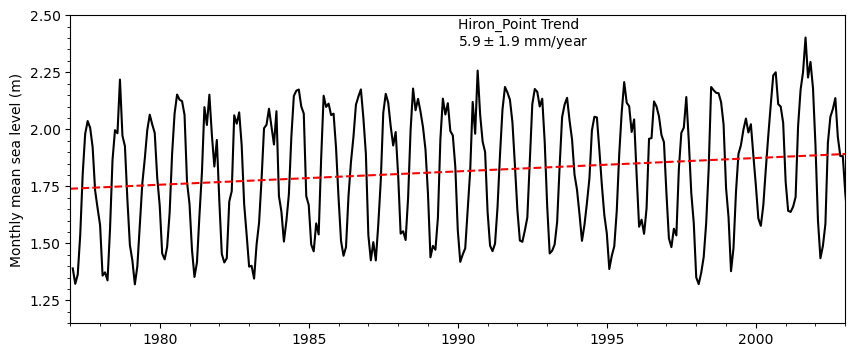

In [23]:
df_mean = df.groupby(pd.Grouper(freq="MS")).mean()
mean = pd.Series(df_mean.Elev.values, index=(df_mean.index.year+df_mean.index.month/12).values)
res = stats.linregress(mean.dropna().index, mean.dropna())
xlim = np.array([df_mean.index.year[0], df_mean.index.year[-1]])
trendline = res.slope * xlim + res.intercept
print(res.slope, res.stderr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean.index, mean, linestyle="-", color="black")
ax.plot(xlim, trendline, linestyle='--', color="red")
ax.annotate(f"{stn_name} Trend\n${res.slope*1000:.1f}\pm{res.stderr*1000:0.1f}$ mm/year", xy=[0.5, 0.9], xycoords="axes fraction")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.set_ylim([1.15, 2.50])
ax.set_ylabel("Monthly mean sea level (m)")
ax.set_xlim(xlim)

TASK: What do you think of this trend value? Can you test what would you get if the series were shorter? Hint: You can cut the mean series.

## Seasonal Sea level variability

0.6852894689220821 0.34264473446104105
1.8189722902334704 1.8219142692529284


Text(0, 0.5, 'Sea level (m) wrt tide gauge zero')

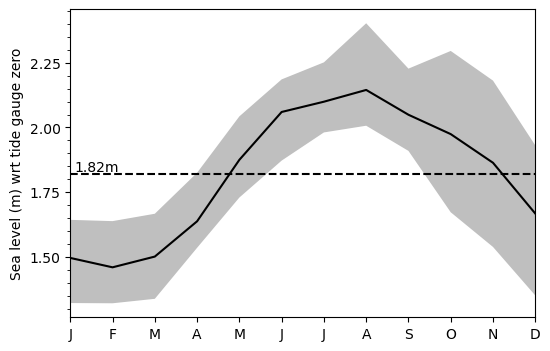

In [24]:
# Seasonal sea level
df_mean = df.groupby(pd.Grouper(freq="MS")).mean()
df_mean_climatology = pd.concat([
    df_mean.groupby(df_mean.index.month).mean().rename(columns={"Elev":"Mean"}),
    df_mean.groupby(df_mean.index.month).max().rename(columns={"Elev":"Max"}),
    df_mean.groupby(df_mean.index.month).min().rename(columns={"Elev":"Min"})
    ], axis=1)

mean_range = df_mean_climatology.Mean.max() - df_mean_climatology.Mean.min()
print(mean_range, mean_range/2)
mean_clim = df_mean_climatology.Mean.mean()
mean_full = df.Elev.mean()
print(mean_clim, mean_full)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_mean_climatology.index, df_mean_climatology.Mean, color="black")
ax.fill_between(
    df_mean_climatology.index,
    y1=df_mean_climatology.Max, 
    y2=df_mean_climatology.Min, 
    facecolor="gray", alpha=0.50)
ax.axhline(mean_full, linestyle='--', color="black")
ax.annotate(text=f"{mean_full:.2f}m", xy=[1.1, mean_full+0.01])
ax.set_xlim([1, 12])
# ax.set_ylim([2.75, 4])
ax.set_xticks(range(1, 13))
ax.set_xticklabels("JFMAMJJASOND")
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.set_ylabel("Sea level (m) wrt tide gauge zero")

TASK: What do you conclude here?

# Harmonic Analysis

UTide is a Unified Tidal Analysis and Prediction package. It was originally developed as a MATLAB package by Daniel L. Codiga (University of Rhode Island) in 2011. 

- It performs harmonic analysis on oceanographic time series data (such as sea level or tidal currents) to decompose signals into constituent harmonic components and predict future tides. 
- It is designed to handle irregularly distributed or gappy time series data and provides robust confidence interval estimates. 
- A Python re-implementation exists, maintained by Wesley Bowman, which is available on PyPI and GitHub. This version adapts the original MATLAB algorithms to Pythonic conventions, supporting both scalar elevation data and vector velocity components.

In [25]:
coef = utide.solve(df.index, df.Elev, lat=stn.latitude, nodal=True, verbose=False)

In [26]:
# Constituents
coef_df = coef2df(coef) # A helper function from pycaz
coef_df

,A,A_ci,g,g_ci
name,,,,
M2,0.807291,0.001011,126.894536,0.071720
S2,0.343023,0.001011,159.094148,0.168791
SA,0.342700,0.004826,218.969747,0.806383
N2,0.161286,0.001011,119.873997,0.358982
K1,0.133407,0.000453,268.042794,0.194702
...,...,...,...,...
3MK7,0.000868,0.000086,233.378932,5.673685
RHO1,0.000845,0.000453,205.335695,30.745638
2SK5,0.000829,0.000140,24.246651,9.647293


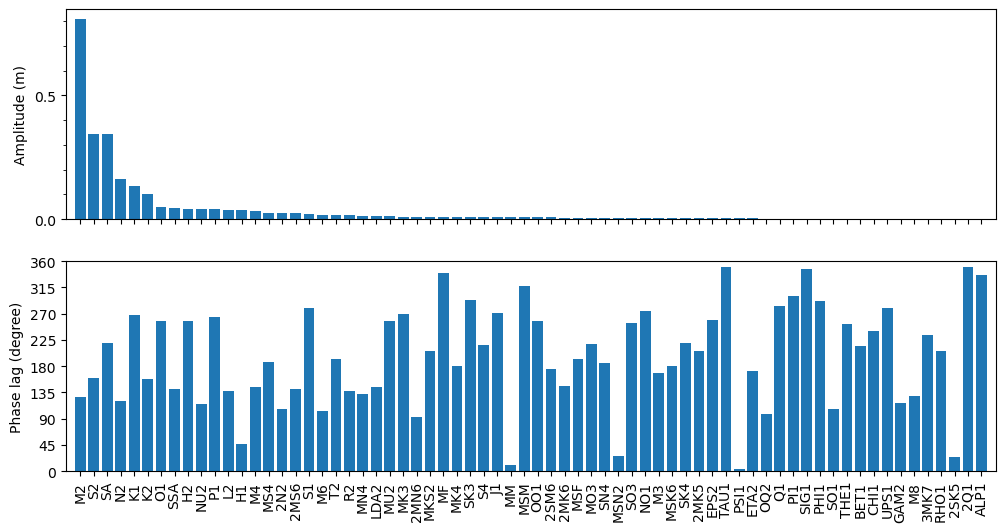

In [27]:
fig, axes = plt.subplots(nrows=2, figsize=(12, 6), sharex=True)
axes[0].bar(coef_df.index, coef_df.A)
axes[0].yaxis.set_major_locator(mticker.MultipleLocator(0.5))
axes[0].yaxis.set_minor_locator(mticker.MultipleLocator(0.1))
axes[0].set_ylabel("Amplitude (m)")

axes[1].bar(coef_df.index, coef_df.g)
axes[1].set_ylim((0, 360))
axes[1].yaxis.set_major_locator(mticker.MultipleLocator(45))
axes[1].set_ylabel("Phase lag (degree)")

for ax in axes:
    ax.tick_params(axis="x", rotation=90)
    ax.margins(x=0.01)

TASK: What do you see here? Please list them here: 

1. e.g., SA
2. 

To do a prediction, we can use utide.reconstruct function. Let us predict for different set of constituents and see how it looks like. We can focus on the timeslice we looked at before.

In [28]:
timeslice

slice('2000-09-27', '2000-11-09', None)

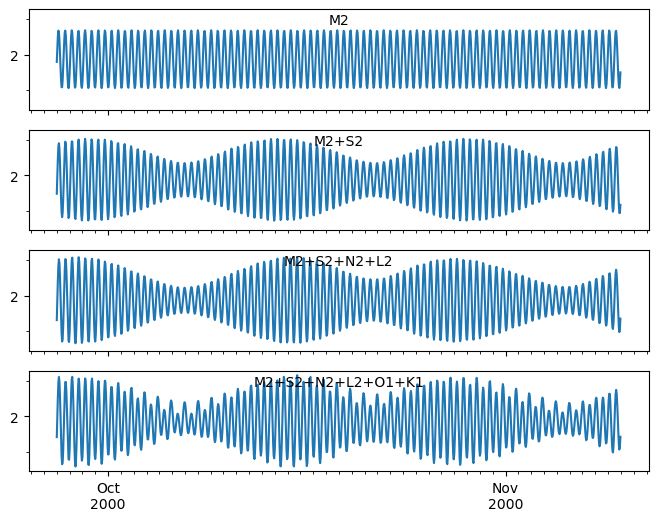

In [29]:
t = df.loc[timeslice].index.values
constits = [
    ["M2"],
    ["M2", "S2"],
    ["M2", "S2", "N2", "L2"],
    ["M2", "S2", "N2", "L2", "O1", "K1"]
]

n_set = len(constits)
fig, axes = plt.subplots(nrows=n_set, figsize=(8, 6), sharex=True, sharey=True)
for i in range(n_set):
    elev = utide.reconstruct(t=t, coef=coef, constit=constits[i], verbose=False)["h"]
    axes[i].plot(t, elev)
    axes[i].annotate(text="+".join(constits[i]), xy=[0.5, 0.85], ha="center", xycoords="axes fraction")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))

plt.show()

We can predict in the future too!

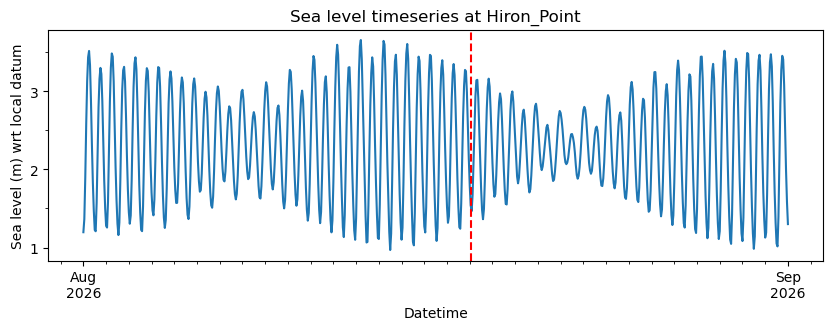

In [30]:
t = pd.date_range(start="2026-08-01", end="2026-09-01", freq="h")
elev_pred = utide.reconstruct(t=t, coef=coef, verbose=False)["h"]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, elev_pred)
ax.axvline(pd.to_datetime("now"), color="red", linestyle="--")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
ax.set(xlabel="Datetime", ylabel="Sea level (m) wrt local datum", title=f"Sea level timeseries at {stn_name}")
plt.show()

# Surge and Non-tidal residual

Total water level = Tide + Non-tidal residual

We can predict tide now, and now we can compute non-tidal residual for the whole series and look at that!

In [31]:
df = df.assign(Tide=utide.reconstruct(t=df.index, coef=coef, verbose=False)["h"])
df = df.assign(NTR=df.Elev -df.Tide)
df.describe()

,Elev,Flag1,Flag2,Tide,NTR
count,234315.000000,234315.0,234315.0,236295.000000,2.343150e+05
mean,1.821914,1.0,1.0,1.821462,-2.106929e-16
std,0.714114,0.0,0.0,0.696856,1.571712e-01
min,-0.200000,1.0,1.0,-0.118398,-9.880669e-01
25%,1.250000,1.0,1.0,1.278159,-9.536955e-02
50%,1.830000,1.0,1.0,1.813835,-5.092163e-03
75%,2.380000,1.0,1.0,2.367425,8.666295e-02
max,4.040000,1.0,1.0,3.637585,2.836742e+00


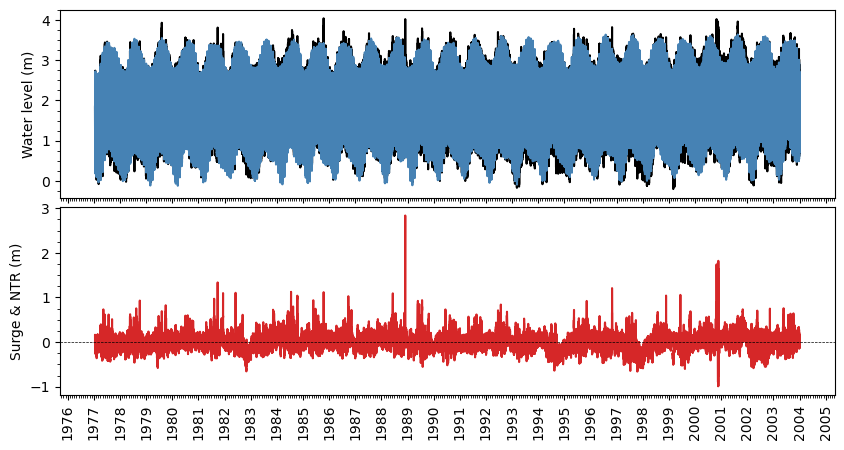

In [32]:
# For full timeseries
fig, axes = plt.subplots(figsize=(10, 5), nrows=2, sharex=True, gridspec_kw={"hspace":0.05})
axes[0].plot(df.index, df.Elev, color="black", label="TWL")
axes[0].plot(df.index, df.Tide, color="steelblue", label="Tide")
axes[0].set_ylabel("Water level (m)")
axes[1].plot(df.index, df.NTR, color="tab:red", label="Surge/NTR")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_ylabel("Surge & NTR (m)")
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter("%d\n%b\n%Y"))
    # ax.xaxis.set_minor_formatter(mdates.DateFormatter("%d"))
    ax.tick_params(axis="x", rotation=90)

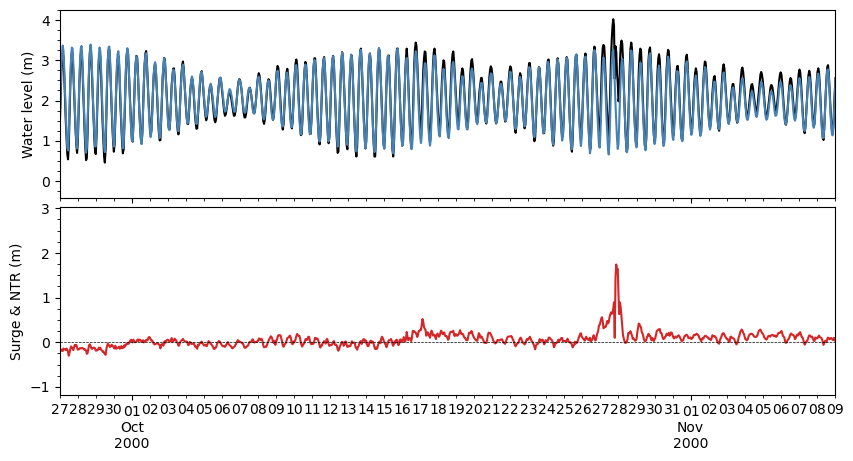

In [33]:
fig, axes = plt.subplots(figsize=(10, 5), nrows=2, sharex=True, gridspec_kw={"hspace":0.05})
axes[0].plot(df.index, df.Elev, color="black", label="TWL")
axes[0].plot(df.index, df.Tide, color="steelblue", label="Tide")
axes[0].set_ylabel("Water level (m)")
axes[1].plot(df.index, df.NTR, color="tab:red", label="Surge/NTR")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_ylabel("Surge & NTR (m)")
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
    ax.set_xlim(pd.to_datetime([timeslice.start, timeslice.stop])) # Change here the datetime in "yyyy-mm-dd" format
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d\n%b\n%Y"))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter("%d"))

Let us look at how the distribution of the tidal and non-tidal residual look like...

Text(1.7, 1.9, 'Min: -0.99m')

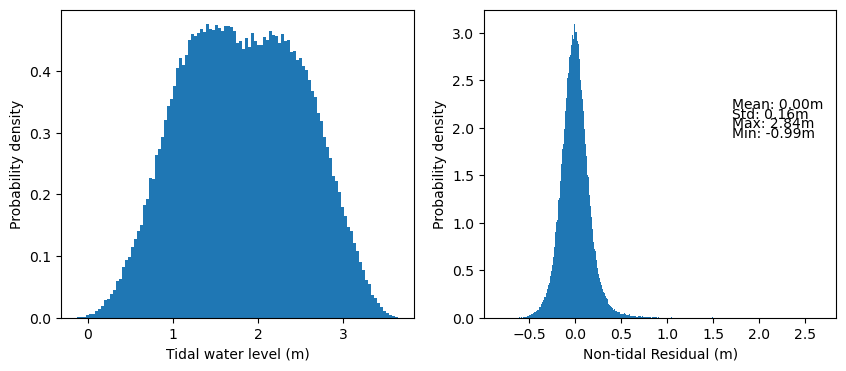

In [34]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Tide
ax = axes[0]
ax.hist(df.Tide.values, bins="fd", density=True)
ax.set_ylabel("Probability density")
ax.set_xlabel("Tidal water level (m)")

tide_mean = df.Tide.mean()
tide_max = df.Tide.max()
tide_min = df.Tide.min()
tide_std = df.Tide.std()

ax.annotate(text=f"Mean: {tide_mean:.2f}", xy=[5.5, 0.23])
ax.annotate(text=f"Std: {tide_std:.2f}m", xy=[5.5, 0.22])
ax.annotate(text=f"Max: {tide_max:.2f}m", xy=[5.5, 0.21])
ax.annotate(text=f"Min: {tide_min:.2f}m", xy=[5.5, 0.20])

# NTR
ax = axes[1]
ax.hist(df.NTR.values, bins="fd", density=True)
ax.set_xmargin(0)
ax.set_ylabel("Probability density")
ax.set_xlabel("Non-tidal Residual (m)")


ntr_mean = df.NTR.mean()
ntr_max = df.NTR.max()
ntr_min = df.NTR.min()
ntr_std = df.NTR.std()

ntr_mean_str = f"{ntr_mean:.2f}m"
if ntr_mean_str == "-0.00m":
    ntr_mean_str = "0.00m"

ax.annotate(text=f"Mean: {ntr_mean_str}", xy=[1.7, 2.2])
ax.annotate(text=f"Std: {ntr_std:.2f}m", xy=[1.7, 2.1])
ax.annotate(text=f"Max: {ntr_max:.2f}m", xy=[1.7, 2])
ax.annotate(text=f"Min: {ntr_min:.2f}m", xy=[1.7, 1.9])

Compare again the with water level residula that we observed with the distribution of tidal water level only, and the distribution of Non-tidal residual.

# Extremes

## Maxima extraction

### Block Maxima and Empirical Distribution

In [35]:
def single_block_maxima(df):
    """Block maxima for a single block, helper function

    Args:
        df (DataSeries): DataSeries on which maximum is computed

    Returns:
        Tuple: [Datetime, MaxValue]
    """
    argmax = df.argmax(skipna=True)
    valmax = df.iloc[argmax]
    datetime = df.index[argmax]
    return datetime, valmax

def block_maxima(series, block="YE"):
    """Extract block maxima

    Args:
        series (DataSeries): DataSeries on which the maxima to be extracted.
        block (str, optional): Block size, pandas freq strings. Defaults to "YE" (YearEnd).

    Returns:
        Series: Series of block maxima
    """
    bm = series.groupby(pd.Grouper(freq="YE")).apply(single_block_maxima).values
    bm = pd.DataFrame({
        "Datetime":[r[0] for r in bm],
        "Elevmax":[r[1] for r in bm]
        })
    bm = bm.set_index("Datetime")
    bm = bm.dropna()

    return bm

In [36]:
# Let us first calculate the block maxima from our data series
df_bm = block_maxima(df.Elev, block="YE")
df_bm.describe()

,Elevmax
count,27.000000
mean,3.698222
std,0.183003
min,3.440000
25%,3.550000
50%,3.670000
75%,3.800000
max,4.040000


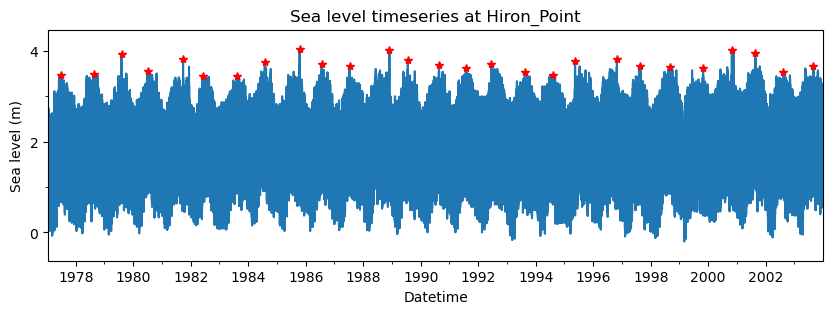

In [37]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df.index, df.Elev)
ax.plot(df_bm.index, df_bm, linestyle="none", marker="*", color="red")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.margins(x=0, y=0.1)
ax.set(xlabel="Datetime", ylabel="Sea level (m)", title=f"Sea level timeseries at {stn_name}")
plt.show()

Task: What do you see? Can you find other maxima that were not picked up? Can you do a block maxima, but for each month, e.g., splitting the timeseries in January values, Feburay values etc.

In [38]:
# Helper function to compute the empirical probability and return periods
# For block maxima approach
def empirical_return_period_bm(data, method='weibull'):
    """
    Computes empirical exceedance probability and return period from block maxima data.
    
    Parameters:
    - data: array-like or pd.Series of block maxima.
    - method: plotting position formula ('weibull', 'gringorten', 'hazen'). Default is 'weibull'.
    
    Returns:
    - pd.DataFrame with sorted values, ranks, exceedance probabilities, and return periods.
    """
    # Clean and sort values in descending order
    vals = np.sort(np.asarray(data, dtype=float).ravel())[::-1]
    vals = vals[~np.isnan(vals)]
    n = len(vals)
    
    # Ranks from 1 (largest) to n (smallest)
    ranks = np.arange(1, n + 1)
    
    # Empirical exceedance probability calculation
    if method == 'weibull':
        p_exceed = ranks / (n + 1)
    elif method == 'gringorten':
        p_exceed = (ranks - 0.44) / (n + 0.12)
    elif method == 'hazen':
        p_exceed = (ranks - 0.5) / n
    else:
        raise ValueError(f"Unsupported method: {method}. Choose 'weibull', 'gringorten', or 'hazen'.")
        
    return_periods = 1.0 / p_exceed
    
    return pd.DataFrame({
        'block_maxima': vals,
        'rank': ranks,
        'exceedance_probability': p_exceed,
        'empirical_return_period': return_periods
    })

In [39]:
emp_bm_output = empirical_return_period_bm(data=df_bm, method="weibull")
emp_bm_output

,block_maxima,rank,exceedance_probability,empirical_return_period
0,4.040,1,0.035714,28.000000
1,4.020,2,0.071429,14.000000
2,4.020,3,0.107143,9.333333
3,3.960,4,0.142857,7.000000
4,3.930,5,0.178571,5.600000
5,3.820,6,0.214286,4.666667
6,3.810,7,0.250000,4.000000
7,3.790,8,0.285714,3.500000
8,3.780,9,0.321429,3.111111
9,3.750,10,0.357143,2.800000


What is the maximum empirical return period we can compute? Length of the data? or more? Why? Ans: Weibull position.

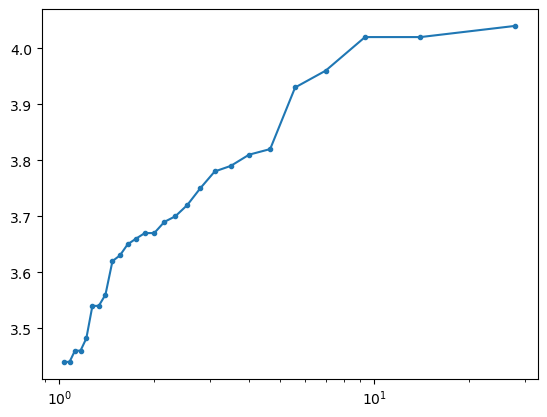

In [40]:
fig, ax = plt.subplots()
ax.plot(emp_bm_output.empirical_return_period, emp_bm_output.block_maxima, marker=".")
ax.set_xscale("log")
ax.margins(0.05)

Task: How the curve may change if we add 0.5m sea level rise? Can you detrend the timeseries and apply it again?

### Peak-over-Threshold (POT) and Empirical Distribution

In [41]:
def peak_over_threshold(series, threshold, over="3D"):
    offset = pd.Timedelta(over) / 2
    pot_series = series.where(series.values >= threshold).dropna()
    pot_series = pot_series.resample("3D", offset=offset).max()
    pot_series = pot_series.dropna()
    return pot_series

We need a threshold here. You can just select the smallest value from your block_maxima selection for now.

In [42]:
threshold = df_bm.min().values
df_pot = peak_over_threshold(series=df.Elev, threshold=threshold, over="3D")

Compare the length between df_pot and df_bm.

In [43]:
# use the len function to calculate length, and print function to print it
# insert your code here

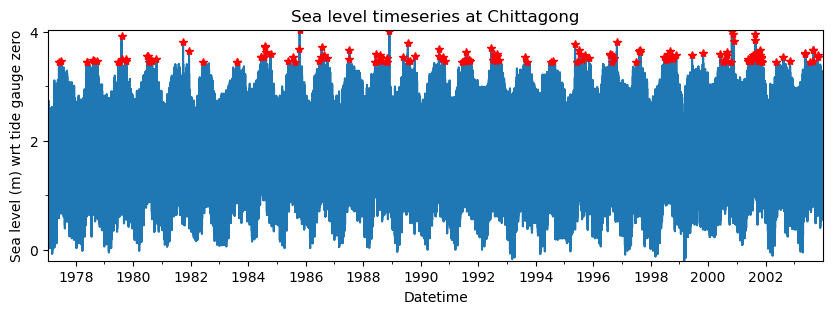

In [44]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df.index, df.Elev)
ax.plot(df_pot.index, df_pot, linestyle="none", marker="*", color="red")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.margins(0)
ax.set(xlabel="Datetime", ylabel="Sea level (m) wrt tide gauge zero", title="Sea level timeseries at Chittagong")
plt.show()

In [45]:
# how many number of events per year?
df_pot_count = df_pot.groupby(pd.Grouper(freq="YE")).count()
df_pot_lambda = df_pot_count.sum()/len(df_pot_count)

print(f"On average {df_pot_lambda:0.02f} events per year")

On average 5.89 events per year


In [46]:
def empirical_return_period_pot(pot_series, total_years, method='weibull'):
    """
    Computes empirical exceedance probability and return period for POT data.
    
    Parameters:
    - pot_series: array-like or pd.Series of peak over threshold values (or exceedances).
    - total_years: float, total duration of the full time-series record in years.
    - method: plotting position formula ('weibull', 'gringorten', 'hazen'). Default is 'weibull'.
    
    Returns:
    - pd.DataFrame with sorted values, ranks, conditional probabilities, 
      annual probabilities, and empirical return periods (in years).
    """
    vals = np.sort(np.asarray(pot_series, dtype=float).ravel())[::-1]
    vals = vals[~np.isnan(vals)]
    k = len(vals)  # Number of exceedances
    
    if k == 0 or total_years <= 0:
        raise ValueError("Must have at least 1 exceedance and positive total_years.")
        
    # Exceedance rate per year (lambda)
    rate = k / total_years
    ranks = np.arange(1, k + 1)
    
    # Conditional exceedance probability P(X > x | X > threshold)
    if method == 'weibull':
        p_cond = ranks / (k + 1)
    elif method == 'gringorten':
        p_cond = (ranks - 0.44) / (k + 0.12)
    elif method == 'hazen':
        p_cond = (ranks - 0.5) / k
    else:
        raise ValueError(f"Unsupported method: {method}. Choose 'weibull', 'gringorten', or 'hazen'.")
        
    # Annual exceedance probability = rate * P(X > x | X > threshold)
    p_annual = rate * p_cond
    return_periods = 1.0 / p_annual
    
    return pd.DataFrame({
        'pot_value': vals,
        'rank': ranks,
        'cond_exceed_prob': p_cond,
        'annual_exceed_prob': p_annual,
        'empirical_return_period': return_periods
    })

In [47]:
total_years=len(df_pot.index.year.unique())
emp_pot_output = empirical_return_period_pot(pot_series=df_pot, total_years=total_years, method='weibull')
emp_pot_output

,pot_value,rank,cond_exceed_prob,annual_exceed_prob,empirical_return_period
0,4.04,1,0.00625,0.036806,27.169811
1,4.02,2,0.01250,0.073611,13.584906
2,4.02,3,0.01875,0.110417,9.056604
3,3.96,4,0.02500,0.147222,6.792453
4,3.96,5,0.03125,0.184028,5.433962
...,...,...,...,...,...
154,3.44,155,0.96875,5.704861,0.175289
155,3.44,156,0.97500,5.741667,0.174165
156,3.44,157,0.98125,5.778472,0.173056
157,3.44,158,0.98750,5.815278,0.171961


In [48]:
# looks like same pot_value is captured a lot of times, making our estimate somewhat misleading
# Higher threshold may stabilize this

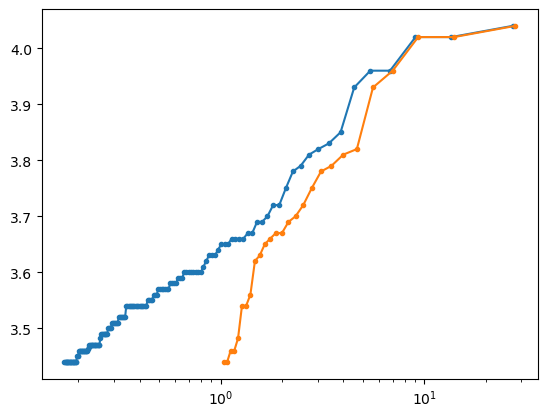

In [49]:
fig, ax = plt.subplots()
ax.plot(emp_pot_output.empirical_return_period, emp_pot_output.pot_value, marker=".", label='Emp POT')
ax.plot(emp_bm_output.empirical_return_period, emp_bm_output.block_maxima, marker=".", label='Emp BM')
ax.set_xscale("log")
ax.margins(0.05)

Looks like our threshold captured a lot of extreme values, too many. Try with other threshold.

### Threshold selection - Mean residual life (plot)

the Mean Residual Life (MRL), also known as the mean excess function, is the primary diagnostic tool used to select an appropriate threshold for Peaks-Over-Threshold (POT) analysis.

Linearity Indicates Validity: we look for the lowest threshold above which the plot exhibits an approximately linear trend. This linearity suggests that the GPD approximation is adequate for exceedances above that point.



In [50]:
def mean_residual_life(data, thresholds, over="3D"):
    """
    Computes the empirical mean residual life for a set of thresholds.
    """
    mrl_values = []
    
    for u in thresholds:
        pot_values = peak_over_threshold(series=data, threshold=u, over=over).values
        if len(pot_values) > 0:
            mrl_values.append(np.mean(pot_values))
        else:
            mrl_values.append(np.nan)
            
    return pd.DataFrame({'threshold': thresholds, 'mean_residual_life': mrl_values})

We will now test different thresholds...

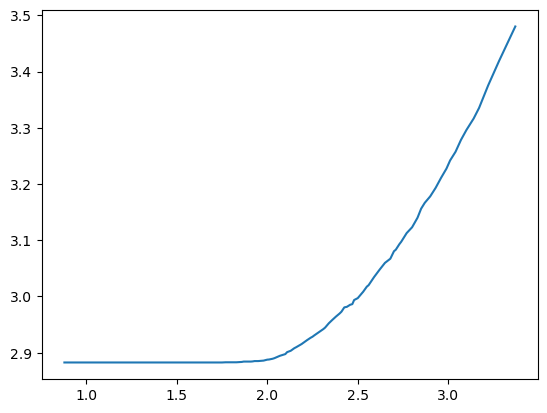

In [51]:
thresholds = df.Elev.quantile(np.arange(0.1, 1, 0.005)).values
mrl = mean_residual_life(df.Elev, thresholds=thresholds)

fig, ax = plt.subplots()
ax.plot(mrl.threshold, mrl.mean_residual_life)

after 3.4, the line seems straight, but not really conclusive.

## Generalized Extreme Value Distribution

Let us write some computational function.

In [52]:
def gev_fit(block_maxima, fix_location=False, loc_value=0.0):
    """
    Fits a GEV distribution using scipy.optimize.minimize and returns 
    fitted parameters, standard errors, and the covariance matrix.
    """
    data = np.asarray(block_maxima)
    
    if fix_location:
        # Initial guess with fixed location
        c_init, _, scale_init = genextreme.fit(data, floc=loc_value)
        init_params = [c_init, scale_init]
        
        def nll(params):
            c, scale = params
            if scale <= 0:
                return np.inf
            return genextreme.nnlf((c, loc_value, scale), data)
            
        res = minimize(nll, init_params, method='BFGS')
        
        c, scale = res.x
        loc = loc_value
        cov_matrix = res.hess_inv  # 2x2 covariance matrix
        
    else:
        # Initial guess for all 3 parameters
        c_init, loc_init, scale_init = genextreme.fit(data)
        init_params = [c_init, loc_init, scale_init]
        
        def nll(params):
            c, loc, scale = params
            if scale <= 0:
                return np.inf
            return genextreme.nnlf((c, loc, scale), data)
            
        res = minimize(nll, init_params, method='BFGS')
        
        c, loc, scale = res.x
        cov_matrix = res.hess_inv  # 3x3 covariance matrix
        
    std_errors = np.sqrt(np.diag(cov_matrix))
    
    return {
        'params': (c, loc, scale),
        'std_errors': std_errors,
        'cov_matrix': cov_matrix,
        'success': res.success
    }

def gev_estimate_return_levels(return_periods, params, cov_matrix, alpha=0.05):
    """
    Estimates return levels and their confidence intervals using the Delta method
    for the Generalized Extreme Value (GEV) distribution using SciPy's parameterization.
    """
    shape, loc, scale = params
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    results = []
    
    for T in return_periods:
        # Non-exceedance probability for return period T
        p = 1 - 1 / T
        y = -np.log(p)
        
        # Calculate return level and partial derivatives for the Delta method
        if np.abs(shape) > 1e-6:
            # Correct sign: loc + (scale / shape) * (1 - y**shape)
            rl = loc + (scale / shape) * (1 - y**shape)
            
            # Partial derivatives w.r.t [shape (c), loc, scale]
            d_shape = - (scale / shape**2) * (1 - y**shape) - (scale / shape) * (y**shape) * np.log(y)
            d_loc = 1.0
            d_scale = (1 - y**shape) / shape
        else:
            # Gumbel limit (shape -> 0)
            rl = loc - scale * np.log(y)
            
            d_shape = - (scale / 2) * (np.log(y)**2)
            d_loc = 1.0
            d_scale = - np.log(y)
            
        # Jacobian vector
        J = np.array([d_shape, d_loc, d_scale])
        
        # Delta method variance: J^T * Cov * J
        var_rl = J.T @ cov_matrix @ J
        se_rl = np.sqrt(var_rl)
        
        results.append({
            'return_period': T,
            'return_level': rl,
            'stderr_return_level': se_rl,
            'return_level_lower_ci': rl - z_alpha * se_rl,
            'return_level_upper_ci': rl + z_alpha * se_rl
        })
        
    return pd.DataFrame(results)

In [53]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    warnings.simplefilter("ignore", category=FutureWarning)

    results = gev_fit(df_bm)
    gev_output = gev_estimate_return_levels(
        return_periods=np.arange(0, 100.1, 0.1), # you can compute any return year
        params=results["params"], 
        cov_matrix=results["cov_matrix"], 
        alpha=0.05)
gev_output

,return_period,return_level,stderr_return_level,return_level_lower_ci,return_level_upper_ci
0,0.0,NaN,NaN,NaN,NaN
1,0.1,NaN,NaN,NaN,NaN
2,0.2,NaN,NaN,NaN,NaN
3,0.3,NaN,NaN,NaN,NaN
4,0.4,NaN,NaN,NaN,NaN
...,...,...,...,...,...
996,99.6,4.170360,0.174739,3.827878,4.512842
997,99.7,4.170447,0.174806,3.827833,4.513061
998,99.8,4.170534,0.174874,3.827788,4.513280
999,99.9,4.170621,0.174941,3.827742,4.513499


Text(0, 0.5, 'Return Level (m)')

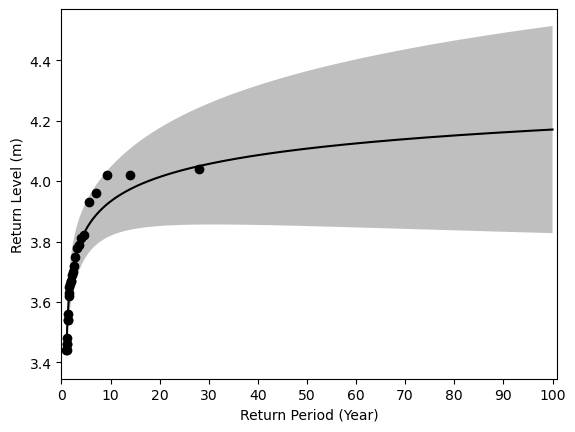

In [54]:
fig, ax = plt.subplots()
ax.plot(gev_output.return_period, gev_output.return_level, color="black")
ax.fill_between(
    gev_output.return_period, 
    y1=gev_output.return_level_lower_ci, 
    y2=gev_output.return_level_upper_ci,
    facecolor="gray",
    alpha=0.5
    )
ax.scatter(emp_bm_output.empirical_return_period, emp_bm_output.block_maxima, color="black")
ax.margins(x=0.01)
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xlabel("Return Period (Year)")
ax.set_ylabel("Return Level (m)")

What do you think about this fit? What do you think about the change in the uncertainty range? How you can use it in your application? 

If we assume in a sea level rise scenario, the same events occurs, and the effect of sea level rise is linear, how would the curve look like? Can you comment on how critical would it be?

## Generalized Pareto Distribution

Let us write the model computation functions.

In [55]:
def gpd_fit(data, threshold=0.0, over="3D", floc=0.0):
    """
    Fits a Generalized Pareto Distribution (GPD) to data and computes 
    the standard errors and covariance of the parameters.
    """
    pot_values = peak_over_threshold(series=data, threshold=threshold, over=over)
    exceedances = pot_values - threshold
    if len(exceedances) == 0:
        raise ValueError("No observations found above the specified threshold.")
    if len(exceedances) < 5:
        print("Warning: Very few exceedances. Estimates may be unstable.")
    
    # Initial parameter estimation using scipy's default fit
    c_init, _, scale_init = genpareto.fit(exceedances, floc=floc)
    
    # Negative log-likelihood function
    def nll(params):
        c, scale = params
        if scale <= 0:
            return np.inf
        return genpareto.nnlf((c, floc, scale), exceedances)
        
    # Minimize NLL to refine parameters and extract the inverse Hessian
    res = minimize(nll, [c_init, scale_init], method='BFGS')
    
    # Extract standard errors and covariance
    se_c, se_scale = np.sqrt(np.diag(res.hess_inv))
    cov_c_scale = res.hess_inv[0, 1]
    
    return {
        'c': res.x[0],
        'scale': res.x[1],
        'loc': floc,
        'stderr_c': se_c,
        'stderr_scale': se_scale,
        'cov_c_scale': cov_c_scale
    }

def gpd_estimate_return_levels(data, threshold, return_periods, fit_params, over="3D", alpha=0.05):
    """
    Estimates return levels and computes the confidence intervals of the return levels 
    using the Delta method, incorporating parameter covariance.
    """
    c = fit_params['c']
    scale = fit_params['scale']
    se_c = fit_params['stderr_c']
    se_scale = fit_params['stderr_scale']
    cov_c_scale = fit_params['cov_c_scale']
    
    # Extract peak over threshold series to calculate the exceedance rate
    pot_series = peak_over_threshold(data, threshold, over=over)
    n_exc = len(pot_series)
    
    # Compute the average number of exceedances per year (lambda)
    # total_years = (data.index.max() - data.index.min()).days / 365.25
    total_years = len(block_maxima(data, block="YE"))
    rate = n_exc / total_years
    var_rate = rate / total_years  # Assuming a Poisson process for the rate variance
    
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    results = []
    
    for T in return_periods:
        # Expected number of exceedances in T years
        y_T = rate * T
        
        # Calculate return level and partial derivatives for the Delta method
        if np.abs(c) > 1e-6:
            rl = threshold + (scale / c) * (y_T**c - 1)
            
            d_scale = (y_T**c - 1) / c
            d_c = - (scale / c**2) * (y_T**c - 1) + (scale / c) * (y_T**c) * np.log(y_T)
            d_rate = scale * (y_T**(c - 1)) * T
        else:
            # Limit case for shape parameter c -> 0 (Gumbel domain)
            rl = threshold + scale * np.log(y_T)
            
            d_scale = np.log(y_T)
            d_c = scale * (np.log(y_T)**2) / 2
            d_rate = scale / rate
            
        # Delta method for variance of the return level including covariance
        var_rl = (d_scale**2) * (se_scale**2) + \
                 (d_c**2) * (se_c**2) + \
                 2 * d_scale * d_c * cov_c_scale + \
                 (d_rate**2) * var_rate
                 
        se_rl = np.sqrt(var_rl)
        
        results.append({
            'return_period': T,
            'return_level': rl,
            'stderr_return_level': se_rl,
            'return_level_lower_ci': rl - z_alpha * se_rl,
            'return_level_upper_ci': rl + z_alpha * se_rl
        })
        
    return pd.DataFrame(results)

Q. How can we automatically compute the threshold? 

A method would be to compute the empirical probability, then check with the modelled probability and minimize the error, such as RMSE.

In [56]:
def optimal_threshold_rmse(data, thresholds, over="3D", min_exceedances=5):
    """
    Finds the optimal threshold by minimizing the RMSE between empirical 
    and theoretical (fitted) non-exceedance probabilities.
    """
    rmse_values = []
    
    for u in thresholds:
        try:
            # 1. Get exceedances and sort them
            pot_series = peak_over_threshold(series=data, threshold=u, over=over)
            exceedances = np.sort(pot_series.values - u)
            n = len(exceedances)
            
            if n < min_exceedances:
                rmse_values.append(np.nan)
                continue
                
            # 2. Compute empirical probability (Weibull plotting position)
            p_emp = np.arange(1, n + 1) / (n + 1)
            
            # 3. Compute fitted parameters
            fit_params = gpd_fit(data=data, threshold=u, over=over)
            c = fit_params['c']
            scale = fit_params['scale']
            
            # 4. Compute theoretical probability and RMSE
            p_th = genpareto.cdf(exceedances, c, loc=0, scale=scale)
            rmse = np.sqrt(np.mean((p_emp - p_th)**2))
            
            rmse_values.append(rmse)
            
        except ValueError:
            rmse_values.append(np.nan)
            
    df_results = pd.DataFrame({'threshold': thresholds, 'rmse': rmse_values})
    best_threshold = df_results.loc[df_results['rmse'].idxmin()]
    
    return df_results, best_threshold

Let us compute both mean residual life and rmse.

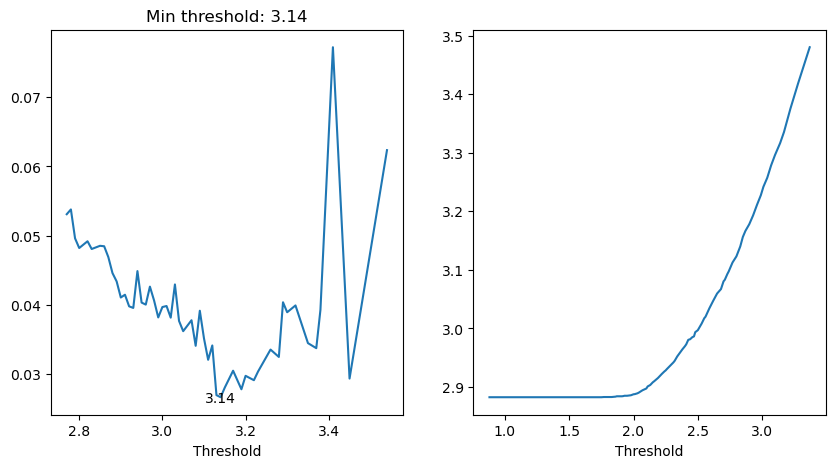

In [59]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    thresholds = df.Elev.quantile(np.arange(0.9, 1, 0.001)).values
    df_rmse, threshold_optimal = optimal_threshold_rmse(data=df.Elev, thresholds=thresholds)


thresholds = df.Elev.quantile(np.arange(0.1, 1, 0.005)).values
mrl = mean_residual_life(df.Elev, thresholds=thresholds)

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
axes[0].plot(df_rmse.threshold, df_rmse.rmse)
axes[0].annotate(text=f"{threshold_optimal.threshold}", xy=[threshold_optimal.threshold, threshold_optimal.rmse*0.97], ha="center")
axes[0].set_title(f"Min threshold: {threshold_optimal.threshold}")

axes[1].plot(mrl.threshold, mrl.mean_residual_life)

for ax in axes:
    ax.set_xlabel("Threshold")

In [72]:
threshold_gpd = threshold_optimal.threshold
# threshold_gpd = 3.44 # to be tried

fit_params = gpd_fit(df.Elev, threshold=threshold_gpd, over="3D", floc=0.0)

return_periods = np.arange(1, 101, 1)

gpd_output = gpd_estimate_return_levels(
    data=df.Elev, 
    threshold=threshold_gpd, 
    return_periods=return_periods, 
    fit_params=fit_params, 
    over="3D", alpha=0.05)

gpd_output

,return_period,return_level,stderr_return_level,return_level_lower_ci,return_level_upper_ci
0,1,3.689145,0.020786,3.648405,3.729886
1,2,3.763182,0.025171,3.713847,3.812517
2,3,3.802657,0.027770,3.748228,3.857086
3,4,3.829078,0.029619,3.771026,3.887130
4,5,3.848710,0.031052,3.787850,3.909571
...,...,...,...,...,...
95,96,4.049799,0.049208,3.953352,4.146245
96,97,4.050343,0.049268,3.953780,4.146906
97,98,4.050880,0.049327,3.954202,4.147559
98,99,4.051412,0.049385,3.954619,4.148204


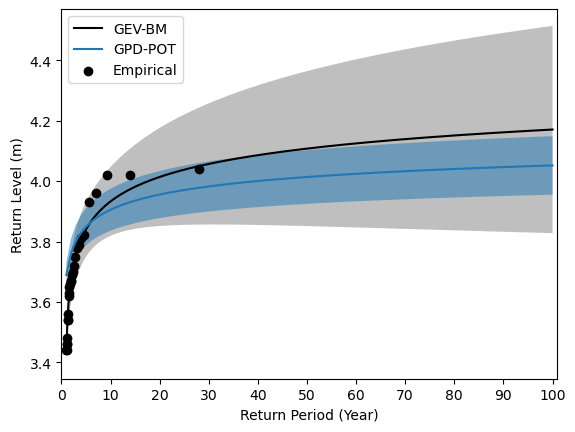

In [73]:
fig, ax = plt.subplots()
# GEV
ax.plot(gev_output.return_period, gev_output.return_level, color="black", label="GEV-BM")
ax.fill_between(
    gev_output.return_period, 
    y1=gev_output.return_level_lower_ci, 
    y2=gev_output.return_level_upper_ci,
    facecolor="gray",
    alpha=0.5
    )

# GPD
ax.plot(gpd_output.return_period, gpd_output.return_level, color="tab:blue", label="GPD-POT")
ax.fill_between(
    gpd_output.return_period, 
    y1=gpd_output.return_level_lower_ci, 
    y2=gpd_output.return_level_upper_ci,
    facecolor="tab:blue",
    alpha=0.5
    )

# Empirical
ax.scatter(emp_bm_output.empirical_return_period, emp_bm_output.block_maxima, color="black", label="Empirical")
ax.margins(x=0.01)
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xlabel("Return Period (Year)")
ax.set_ylabel("Return Level (m)")
plt.legend()

What do you think about the GPD fit? Are you seeing the values converging? Can you see how the threshold values may impact the fitting?

Bonus discussion: 

1. If we now want to take this value and project on a bathymetry/topography to see how much area will be flooded, what would be our challenges?
2. Can you think of using this for setting important heights, such as embankments?


Open discussion.